# Hospital Operations Intelligence Platform

## Notebook 06: Bed Occupancy Forecast

### Business objective

Forecast occupied-bed demand so administrators can plan staffing, discharge
coordination, elective scheduling, and surge capacity.

### Problem

Time-series regression using a daily active-patient census. A 500-bed staffed
capacity is an explicit portfolio assumption and can be changed before training.

### Models

Seven-day moving-average baseline, XGBoost time-series regressor, and optional
Prophet benchmark. Output is a dated 30-day forecast.

## 1. Imports and daily census construction

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
INTERIM = ROOT / "datasets" / "interim"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
EXPERIMENT_MODELS = MODELS / "experiments"
EXPERIMENT_REPORTS = REPORTS / "experiments"
for folder in [INTERIM, PROCESSED, MODELS, REPORTS, EXPERIMENT_MODELS, EXPERIMENT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
BED_CAPACITY = 500

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
data_path = INTERIM / "notebook_model_features.csv"
data = pd.read_csv(data_path, parse_dates=["admit_date", "discharge_date"])
calendar = pd.date_range(data["admit_date"].min(), data["admit_date"].max(), freq="D")
admissions = data.groupby("admit_date").size().reindex(calendar, fill_value=0)
discharges = (
    data.groupby(data["discharge_date"] + pd.Timedelta(days=1))
    .size()
    .reindex(calendar, fill_value=0)
)
occupied = (admissions - discharges).cumsum().clip(lower=0)
daily = pd.DataFrame(
    {
        "date": calendar,
        "admissions": admissions.values,
        "discharges": discharges.values,
        "occupied_beds": occupied.values,
    }
)
daily["available_beds"] = (BED_CAPACITY - daily["occupied_beds"]).clip(lower=0)
daily["occupancy_pct"] = (daily["occupied_beds"] / BED_CAPACITY * 100).clip(0, 100)
display(daily.tail())

,date,admissions,discharges,occupied_beds,available_beds,occupancy_pct
3647,2024-12-26,38,28,286,214,57.2
3648,2024-12-27,44,43,287,213,57.4
3649,2024-12-28,22,45,264,236,52.8
3650,2024-12-29,27,35,256,244,51.2
3651,2024-12-30,36,29,263,237,52.6


## 2. Validation and time-series features

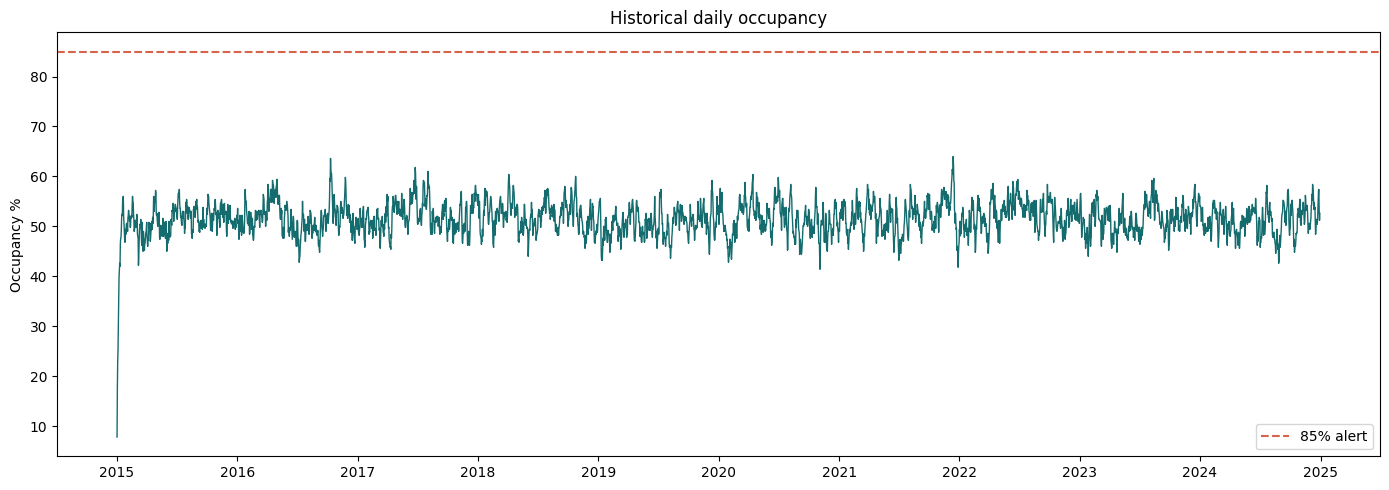

In [3]:
assert daily["date"].is_monotonic_increasing
assert daily["date"].duplicated().sum() == 0
assert (daily["occupied_beds"] >= 0).all()

daily["dayofweek"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["is_weekend"] = (daily["dayofweek"] >= 5).astype(int)
daily["lag_1"] = daily["occupancy_pct"].shift(1)
daily["lag_7"] = daily["occupancy_pct"].shift(7)
daily["rolling_7"] = daily["occupancy_pct"].shift(1).rolling(7).mean()
daily["moving_average_7"] = daily["occupancy_pct"].shift(1).rolling(7).mean()
model_data = daily.dropna().copy()

plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["occupancy_pct"], color="#146C6E", linewidth=1)
plt.axhline(85, linestyle="--", color="#D7644A", label="85% alert")
plt.title("Historical daily occupancy")
plt.ylabel("Occupancy %")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Moving-average and ML evaluation

In [4]:
features = ["dayofweek", "month", "is_weekend", "lag_1", "lag_7", "rolling_7"]
split = int(len(model_data) * 0.80)
train = model_data.iloc[:split]
test = model_data.iloc[split:]
X_train, y_train = train[features], train["occupancy_pct"]
X_test, y_test = test[features], test["occupancy_pct"]

try:
    from xgboost import XGBRegressor
    model = XGBRegressor(
        n_estimators=120, max_depth=3, learning_rate=0.06, random_state=42
    )
except ImportError:
    model = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)
ml_prediction = model.predict(X_test)
baseline_prediction = test["moving_average_7"].to_numpy()

metrics = pd.DataFrame(
    [
        {
            "model": "moving_average_7",
            "MAE": mean_absolute_error(y_test, baseline_prediction),
            "RMSE": np.sqrt(mean_squared_error(y_test, baseline_prediction)),
            "R2": r2_score(y_test, baseline_prediction),
        },
        {
            "model": type(model).__name__,
            "MAE": mean_absolute_error(y_test, ml_prediction),
            "RMSE": np.sqrt(mean_squared_error(y_test, ml_prediction)),
            "R2": r2_score(y_test, ml_prediction),
        },
    ]
).sort_values("RMSE")
display(metrics)

,model,MAE,RMSE,R2
1,XGBRegressor,1.271671,1.593769,0.690117
0,moving_average_7,1.908211,2.386735,0.305046


## 4. Optional Prophet benchmark

In [5]:
try:
    from prophet import Prophet
    prophet_data = daily[["date", "occupancy_pct"]].rename(
        columns={"date": "ds", "occupancy_pct": "y"}
    )
    prophet_model = Prophet(
        weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False
    )
    prophet_model.fit(prophet_data)
    prophet_future = prophet_model.make_future_dataframe(periods=30)
    prophet_forecast = prophet_model.predict(prophet_future).tail(30)
    print("Prophet benchmark completed.")
except ImportError:
    prophet_forecast = None
    print("Prophet is optional and not installed.")

Prophet is optional and not installed.


## 5. Recursive 30-day forecast

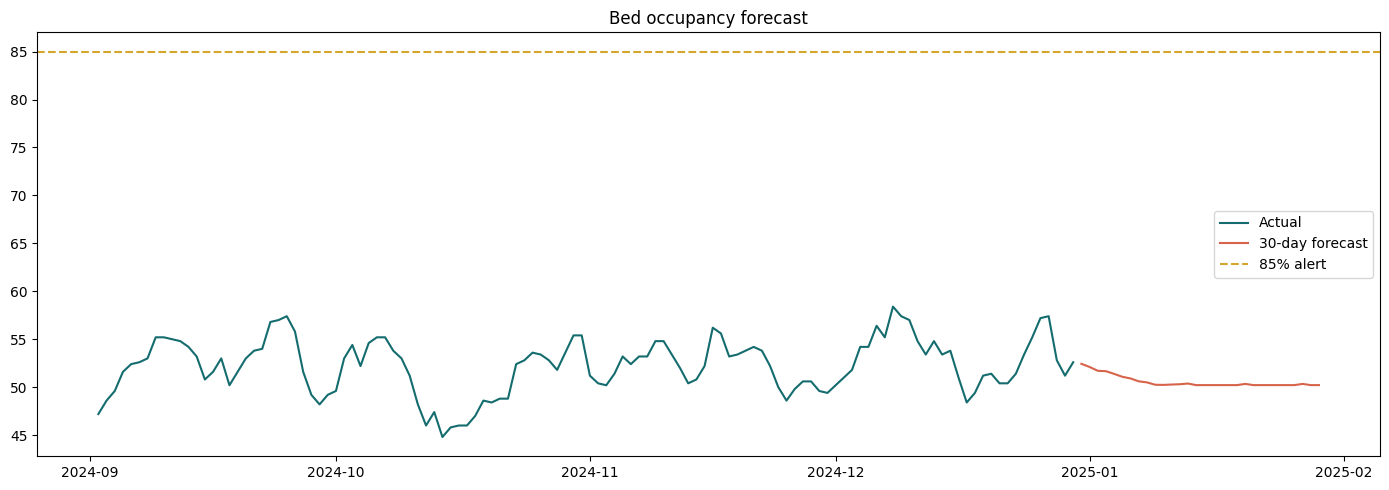

In [6]:
history = daily.set_index("date")["occupancy_pct"].to_dict()
forecast_rows = []
last_date = daily["date"].max()
for step in range(1, 31):
    forecast_date = last_date + pd.Timedelta(days=step)
    prior = [history[forecast_date - pd.Timedelta(days=i)] for i in range(1, 8)]
    row = pd.DataFrame(
        [
            {
                "dayofweek": forecast_date.dayofweek,
                "month": forecast_date.month,
                "is_weekend": int(forecast_date.dayofweek >= 5),
                "lag_1": prior[0],
                "lag_7": prior[6],
                "rolling_7": np.mean(prior),
            }
        ]
    )
    occupancy = float(np.clip(model.predict(row[features])[0], 0, 100))
    history[forecast_date] = occupancy
    forecast_rows.append(
        {
            "date": forecast_date,
            "forecast_occupancy_pct": occupancy,
            "forecast_occupied_beds": int(np.ceil(occupancy / 100 * BED_CAPACITY)),
            "forecast_available_beds": int(
                max(BED_CAPACITY - np.ceil(occupancy / 100 * BED_CAPACITY), 0)
            ),
        }
    )
forecast = pd.DataFrame(forecast_rows)

plt.figure(figsize=(14, 5))
plt.plot(
    daily.tail(120)["date"], daily.tail(120)["occupancy_pct"],
    label="Actual", color="#146C6E"
)
plt.plot(
    forecast["date"], forecast["forecast_occupancy_pct"],
    label="30-day forecast", color="#D7644A"
)
plt.axhline(85, linestyle="--", color="#D4A72C", label="85% alert")
plt.legend()
plt.title("Bed occupancy forecast")
plt.tight_layout()
plt.show()

## 6. Save model, forecast, and conclusions

In [7]:
artifact = {
    "model": model,
    "features": features,
    "bed_capacity": BED_CAPACITY,
    "last_date": last_date,
}
joblib.dump(artifact, EXPERIMENT_MODELS / "occupancy_notebook.pkl")
forecast.to_csv(EXPERIMENT_REPORTS / "occupancy_30_day_forecast.csv", index=False)
metrics.to_csv(EXPERIMENT_REPORTS / "occupancy_metrics.csv", index=False)
print("Saved:", EXPERIMENT_MODELS / "occupancy_notebook.pkl")

Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\models\experiments\occupancy_notebook.pkl


## Business conclusions

- Daily active census is more meaningful than admission count alone.
- Lagged occupancy provides strong short-term signal but uncertainty grows recursively.
- The forecast supports staffing and capacity scenarios; it does not prove that
  a physical bed is staffed, clean, or appropriate for a specific clinical need.
- Department-level bed inventory and scheduled procedures would improve the forecast.